In [1]:
import pandas as pd

# Load your data
data = pd.read_csv(r"C:\Manas\i-DiagnOCe\i-DiagnOCe - project handover data\Weather data\Integrated_Data_23_24.csv")

# Convert 'Date' column to datetime with dayfirst=True
data['Date'] = pd.to_datetime(data['Date'], format='%Y-%m-%d %H:%M:%S')

# Extract the time part
data['Time'] = data['Date'].dt.time

# Extract the date part (ignoring time)
data['Date'] = data['Date'].dt.date

# Filter for 8:30 AM and 2:30 PM
filtered_data = data[data['Time'].isin([pd.to_datetime("08:30", format="%H:%M").time(),
                                        pd.to_datetime("14:30", format="%H:%M").time()])]

# Pivot to create separate columns for RH at 8:30 AM and 2:30 PM
pivoted_data = filtered_data.pivot(index='Date', columns='Time', values='RH(%)').reset_index()
# print(pivoted_data)

# Rename columns for clarity
pivoted_data.columns = ['Date', 'RH_8_30_AM', 'RH_2_30_PM']

# Extract Rain(mm) values at 8:30 AM for each day
rain_8_30_am = data[data['Time'] == pd.to_datetime("08:30", format="%H:%M").time()][['Date', 'Rain(mm)']]
rain_8_30_am = rain_8_30_am.rename(columns={'Rain(mm)': 'Rain_8_30_AM'})

# Aggregate the full dataset to compute daily averages, totals, min, and max temperatures
daily_aggregates = data.groupby('Date').agg(
    Avg_Temp=('Temp', 'mean'),
    Avg_RH=('RH(%)', 'mean'),
    Min_Temp=('Temp', 'min'),
    Max_Temp=('Temp', 'max')
).reset_index()

# Merge all the data: RH, rain at 8:30 AM, and daily aggregates
final_data = pd.merge(pivoted_data, daily_aggregates, on='Date', how='left')
final_data = pd.merge(final_data, rain_8_30_am, on='Date', how='left')

# Convert 'Day' column to datetime for rolling operations
final_data['Date'] = pd.to_datetime(final_data['Date'])

# Sort by date
final_data = final_data.sort_values(by='Date')

# Set 'Day' as index for rolling calculations
final_data.set_index('Date', inplace=True)

# Calculate 7-day rolling averages, sums, and other statistics
final_data['Avg_Temp_7d'] = final_data['Avg_Temp'].rolling(window=7).mean()
final_data['Avg_RH_7d'] = final_data['Avg_RH'].rolling(window=7).mean()
final_data['Min_Temp_7d'] = final_data['Min_Temp'].rolling(window=7).min()
final_data['Max_Temp_7d'] = final_data['Max_Temp'].rolling(window=7).max()
final_data['Rain_8_30_AM_7d'] = final_data['Rain_8_30_AM'].rolling(window=7).sum()

# Calculate 14-day rolling averages, sums, and other statistics
final_data['Avg_Temp_14d'] = final_data['Avg_Temp'].rolling(window=14).mean()
final_data['Avg_RH_14d'] = final_data['Avg_RH'].rolling(window=14).mean()
final_data['Min_Temp_14d'] = final_data['Min_Temp'].rolling(window=14).min()
final_data['Max_Temp_14d'] = final_data['Max_Temp'].rolling(window=14).max()
final_data['Rain_8_30_AM_14d'] = final_data['Rain_8_30_AM'].rolling(window=14).sum()

# Reset index for saving or further processing
final_data.reset_index(inplace=True)

# Save the final data with 7-day and 14-day aggregated columns
# final_data.to_csv("weather_data.csv", index=False)

print("Data saved with 7-day and 14-day aggregated time points!")

Data saved with 7-day and 14-day aggregated time points!


In [11]:
data[data['Time'] == pd.to_datetime('08:30', format='%H:%M').time()]

,Unnamed: 0,Date,Temp,RH(%),Rain(mm),Time
34,34,2023-01-01,16.5,85.0,0.0,08:30:00
129,129,2023-01-02,16.7,75.0,0.0,08:30:00
223,223,2023-01-03,16.8,77.0,0.0,08:30:00
317,317,2023-01-04,18.1,79.0,0.0,08:30:00
412,412,2023-01-05,18.1,84.0,0.0,08:30:00
...,...,...,...,...,...,...
32422,32422,2023-12-27,18.8,86.0,0.0,08:30:00
32515,32515,2023-12-28,17.9,83.0,0.0,08:30:00
32607,32607,2023-12-29,18.3,88.0,0.0,08:30:00
32698,32698,2023-12-30,16.4,88.0,0.0,08:30:00


In [10]:
data[(data['Time'] == pd.to_datetime('14:30', format='%H:%M').time())]

,Unnamed: 0,Date,Temp,RH(%),Rain(mm),Time
58,58,2023-01-01,32.6,20.0,0.0,14:30:00
153,153,2023-01-02,31.5,32.0,0.0,14:30:00
247,247,2023-01-03,30.8,35.0,0.0,14:30:00
341,341,2023-01-04,29.7,42.0,0.0,14:30:00
435,435,2023-01-05,28.3,50.0,0.0,14:30:00
...,...,...,...,...,...,...
32351,32351,2023-12-26,33.7,29.0,0.0,14:30:00
32446,32446,2023-12-27,32.6,32.0,0.0,14:30:00
32539,32539,2023-12-28,30.4,39.0,0.0,14:30:00
32722,32722,2023-12-30,31.5,30.0,0.0,14:30:00


In [13]:
pivoted_data['RH_8_30_AM']

0      85.0
1      75.0
2      77.0
3      79.0
4      84.0
       ... 
342    86.0
343    83.0
344    88.0
345    88.0
346    83.0
Name: RH_8_30_AM, Length: 347, dtype: float64

In [2]:
import pandas as pd
# Load your data
weather_data = pd.read_csv('data.csv')
Disease_data = pd.read_csv('disease .csv')

# Convert 'Date' columns to datetime format
weather_data['Date'] = pd.to_datetime(weather_data['Date'], format='%d-%m-%Y', dayfirst=True)
Disease_data['Date'] = pd.to_datetime(Disease_data['Date'], format='%d-%m-%Y', dayfirst=True)
# Merge the two DataFrames on 'Date' using inner join to keep only disease observation dates
merged_data = pd.merge(Disease_data, weather_data, on='Date', how='inner')



# Display the merged data
print(merged_data.head())


# Filter the merged data for Kharif season and treatments T4 and T2
filtered_data = merged_data[(merged_data['Season'] == 'Rabi') & (merged_data['Treatment'].isin(['T4','T2']))]
# Create binary target variables for each disease
filtered_data['Disease_SB_Present'] = (filtered_data['AUDPC_SB'] > 0).astype(int)
filtered_data['Disease_PB_Present'] = (filtered_data['AUDPC_PB'] > 0).astype(int)
filtered_data['Disease_AN_Present'] = (filtered_data['AUDPC_AN'] > 0).astype(int)



# Display the filtered data
print(filtered_data.columns)

        Date  Season Trial_name  Days Treatment  PDI_SB  PDI_PB  PDI_AN  \
0 2023-07-13  Kharif   Trial  1     2        T2     0.0     0.0     0.0   
1 2023-07-17  Kharif   Trial  1     6        T2     0.0     0.0     0.0   
2 2023-07-20  Kharif   Trial  1     9        T2     0.0     0.0     0.0   
3 2023-07-24  Kharif   Trial  1    13        T2     0.0     0.0     0.0   
4 2023-07-27  Kharif   Trial  1    16        T2     0.0     0.0     0.0   

   AUDPC_SB  AUDPC_PB  ...  Total_Rain_14d  Max_Temp_14d  Min_Temp_14d  \
0       0.0       0.0  ...            43.0          31.5     23.814286   
1       0.0       0.0  ...            16.0          31.5     23.850000   
2       0.0       0.0  ...            31.0          30.6     23.664286   
3       0.0       0.0  ...            41.0          30.3     23.542857   
4       0.0       0.0  ...            59.5          30.3     23.307143   

   RH_8_30_2w  RH_2_30_2w  Avg_Temp_2w  Avg_RH_2w  Total_Rain_2w  Max_Temp_2w  \
0   86.700000   79.0857

C:\Users\manas\AppData\Local\Temp\ipykernel_18288\3350012697.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Disease_SB_Present'] = (filtered_data['AUDPC_SB'] > 0).astype(int)
C:\Users\manas\AppData\Local\Temp\ipykernel_18288\3350012697.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Disease_PB_Present'] = (filtered_data['AUDPC_PB'] > 0).astype(int)
C:\Users\manas\AppData\Local\Temp\ipykernel_18288\3350012697.py:23: SettingWithCopyWarning: 
A value is trying to be set

Accuracy: 0.7368421052631579
Confusion Matrix:
 [[ 3  2]
 [ 3 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.60      0.55         5
           1       0.85      0.79      0.81        14

    accuracy                           0.74        19
   macro avg       0.67      0.69      0.68        19
weighted avg       0.76      0.74      0.74        19


Feature Importances:
        Feature  Importance
5    Avg_RH_14d    0.282602
1    RH_2_30_7d    0.178160
3     Avg_RH_7d    0.159488
0    RH_8_30_7d    0.134088
7   Min_Temp_7d    0.086086
4  Avg_Temp_14d    0.061028
2   Avg_Temp_7d    0.058593
6   Max_Temp_7d    0.039954


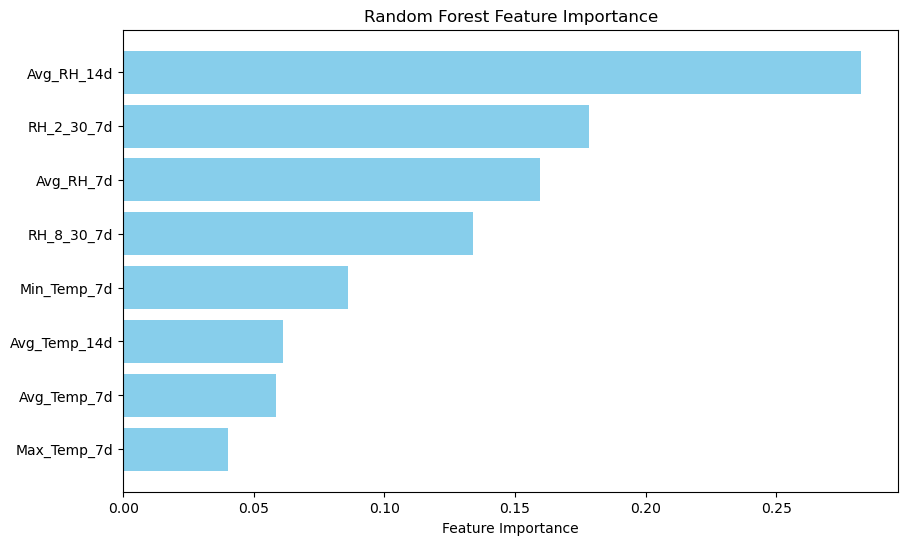

Model saved to C:\Users\Suresh Gawande\Desktop\New folder\rf_model_AN.joblib


In [51]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt
import joblib
# Use weather-related features as predictors
X = filtered_data[['RH_8_30_7d', 'RH_2_30_7d', 'Avg_Temp_7d', 'Avg_RH_7d','Avg_Temp_14d', 'Avg_RH_14d',
                   'Max_Temp_7d', 'Min_Temp_7d']]
y = filtered_data['Disease_AN_Present']  # Binary target                                                                                                              

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Combine feature names and importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()
# Path to save the Random Forest model
save_path = r'C:\Users\Suresh Gawande\Desktop\New folder\rf_model_AN.joblib'

# Save the trained model
joblib.dump(rf_model, save_path)

print(f"Model saved to {save_path}")

In [ ]:
import pandas as pd
from lifelines import CoxPHFitter



# Convert categorical columns
filtered_data['Trial_name'] = filtered_data['Trial_name'].astype('category').cat.codes
filtered_data['Season'] = filtered_data['Season'].astype('category').cat.codes

data_for_model = filtered_data[['Days', 'Disease_AN_Present',  'Avg_Temp_7d', 'Avg_RH_7d','Avg_Temp_14d','Avg_RH_14d',
        'Max_Temp_7d', 'Min_Temp_7d','Trial_name']]  # Use the new column

cph = CoxPHFitter()
cph.fit(data_for_model, duration_col='Days', event_col='Disease_AN_Present')
cph.print_summary()

import joblib

# Path to save the CoxPH model
save_path = r'C:\Users\Suresh Gawande\Desktop\New folder\cph_model_AN.joblib'

# Save the CoxPH model
joblib.dump(cph, save_path)

print(f"CoxPH model saved to {save_path}")

C:\Users\Suresh Gawande\AppData\Local\Temp\ipykernel_4480\4290683797.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Trial_name'] = filtered_data['Trial_name'].astype('category').cat.codes
C:\Users\Suresh Gawande\AppData\Local\Temp\ipykernel_4480\4290683797.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Season'] = filtered_data['Season'].astype('category').cat.codes


<lifelines.CoxPHFitter: fitted with 94 total observations, 26 right-censored observations>
             duration col = 'Days'
                event col = 'Disease_AN_Present'
      baseline estimation = breslow
   number of observations = 94
number of events observed = 68
   partial log-likelihood = -139.06
         time fit was run = 2024-12-30 11:11:13 UTC

---
              coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                     
Avg_Temp_7d  -0.36      0.70      0.72           -1.77            1.04                0.17                2.83
Avg_RH_7d     0.50      1.65      0.11            0.29            0.72                1.33                2.05
Avg_Temp_14d  0.49      1.63      0.35           -0.20            1.17                0.82                3.23
Avg_RH_14d    0.68      1.97      0.14            0.41            0.94                1.51                2.56
Max_Temp_7d   1.23      3.43      0.28            0.69            1.78                1.99                5.94
Min_Temp_7d  -0.83      0.44      0.39           -1.59           -0.06                0.20                0.94
Trial_name    5.66    287.26      0.88            3.93            7.39               51.06             1615.95

              cmp to     z      p  -log2(p)
covariate                                  
Avg_Temp_7d     0.00 -0.51   0.61      0.71
Avg_RH_7d       0.00  4.56 <0.005     17.57
Avg_Temp_14d    0.00  1.39   0.17      2.59
Avg_RH_14d      0.00  5.00 <0.005     20.72
Max_Temp_7d     0.00  4.41 <0.005     16.59
Min_Temp_7d     0.00 -2.12   0.03      4.87
Trial_name      0.00  6.42 <0.005     32.80
---
Concordance = 0.92
Partial AIC = 292.12
log-likelihood ratio test = 166.14 on 7 df
-log2(p) of ll-ratio test = 105.59

CoxPH model saved to C:\Users\Suresh Gawande\Desktop\New folder\cph_model_AN.joblib


In [33]:
thresholds = data_for_model[[ 'Avg_RH_7d',  'Avg_RH_14d',
                             'Max_Temp_7d', 'Min_Temp_7d']].quantile([0.25, 0.5, 0.75])
print(thresholds)


      Avg_RH_7d  Avg_RH_14d  Max_Temp_7d  Min_Temp_7d
0.25  52.811458   56.027179    30.575000    12.403571
0.50  62.013724   64.115319    32.300000    13.400000
0.75  66.042062   66.459952    34.064286    14.828571


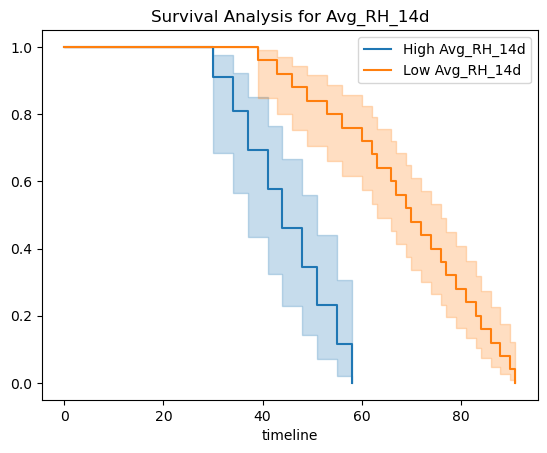

In [35]:
from lifelines import KaplanMeierFitter

kmf = KaplanMeierFitter()

# Example for Avg_RH_14d
median_threshold = data_for_model['Avg_RH_14d'].median()
high_rh = data_for_model['Avg_RH_14d'] > median_threshold

kmf.fit(data_for_model['Days'][high_rh], event_observed=data_for_model['Disease_AN_Present'][high_rh], label='High Avg_RH_14d')
kmf.plot_survival_function()

kmf.fit(data_for_model['Days'][~high_rh], event_observed=data_for_model['Disease_AN_Present'][~high_rh], label='Low Avg_RH_14d')
kmf.plot_survival_function()

plt.title('Survival Analysis for Avg_RH_14d')
plt.show()


In [37]:
from lifelines.statistics import logrank_test

# Example: Test for Avg_RH_14d
high_group = data_for_model[data_for_model['Avg_RH_14d'] > median_threshold]
low_group = data_for_model[data_for_model['Avg_RH_14d'] <= median_threshold]

result = logrank_test(high_group['Days'], low_group['Days'], event_observed_A=high_group['Disease_AN_Present'], event_observed_B=low_group['Disease_AN_Present'])
print(result.p_value)

6.792652170037952e-12


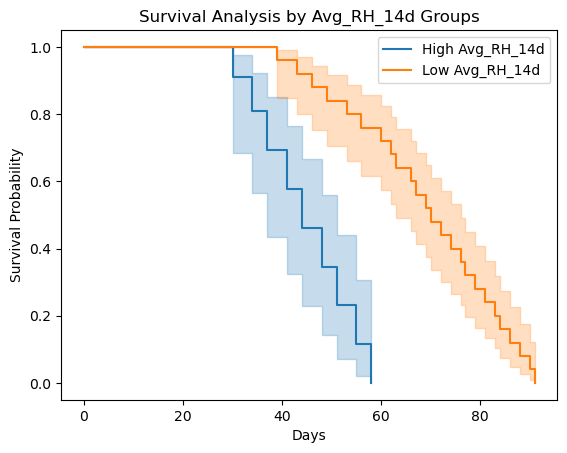

In [41]:
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

kmf = KaplanMeierFitter()

# High group
kmf.fit(high_group['Days'], event_observed=high_group['Disease_AN_Present'], label='High Avg_RH_14d')
ax = kmf.plot_survival_function()

# Low group
kmf.fit(low_group['Days'], event_observed=low_group['Disease_AN_Present'], label='Low Avg_RH_14d')
kmf.plot_survival_function(ax=ax)

plt.title('Survival Analysis by Avg_RH_14d Groups')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.show()


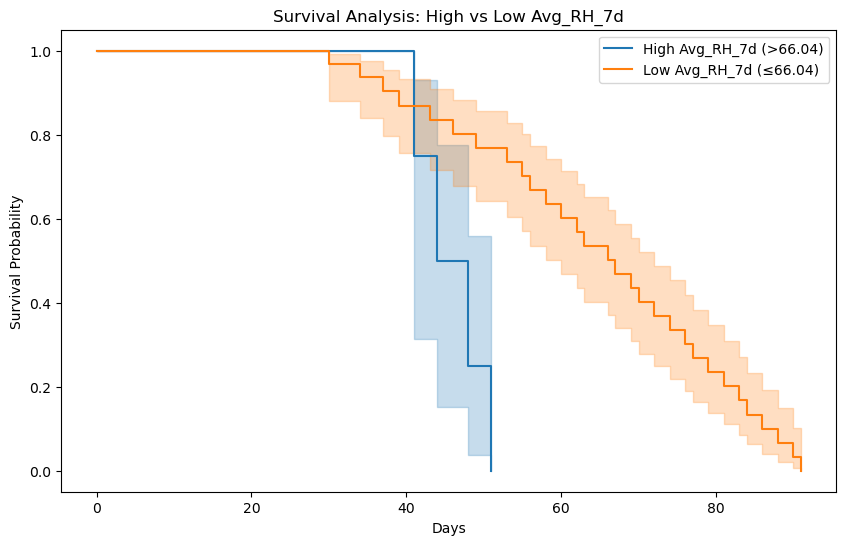

In [43]:
# Example for Avg_RH_7d
high_group = data_for_model[data_for_model['Avg_RH_7d'] > 66.04]
low_group = data_for_model[data_for_model['Avg_RH_7d'] <= 66.04]

kmf_high = KaplanMeierFitter()
kmf_low = KaplanMeierFitter()

# Plot
plt.figure(figsize=(10, 6))
kmf_high.fit(high_group['Days'], event_observed=high_group['Disease_AN_Present'], label='High Avg_RH_7d (>66.04)')
ax = kmf_high.plot_survival_function()

kmf_low.fit(low_group['Days'], event_observed=low_group['Disease_AN_Present'], label='Low Avg_RH_7d (≤66.04)')
kmf_low.plot_survival_function(ax=ax)

plt.title('Survival Analysis: High vs Low Avg_RH_7d')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.legend()
plt.show()


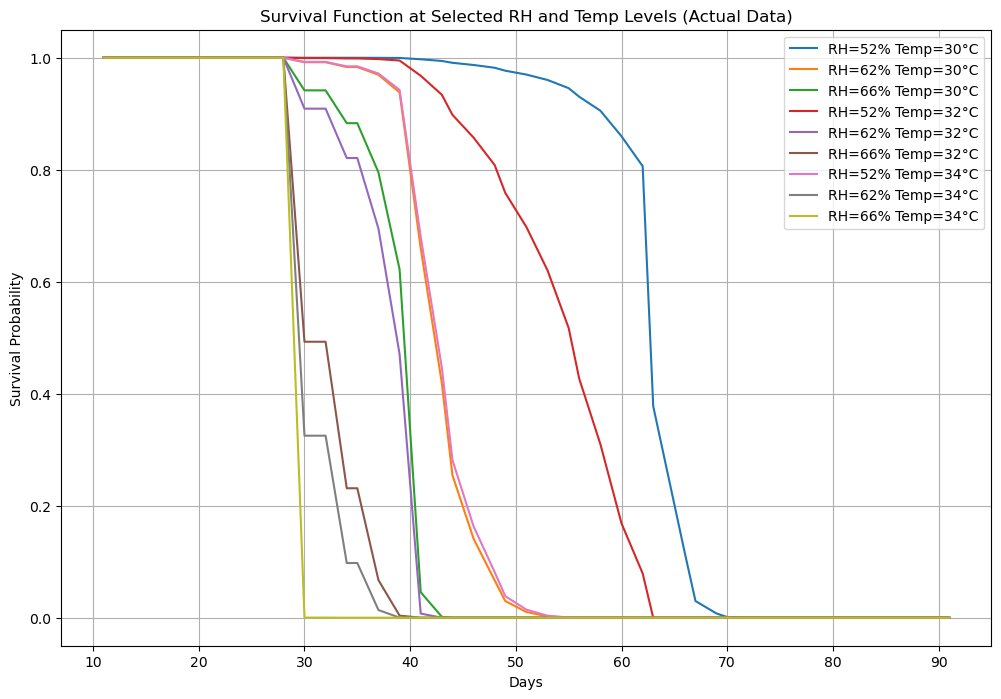

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from lifelines import CoxPHFitter
import pandas as pd

# Manually select a few specific RH and Temp values (for example)
selected_rh_values = [52, 62, 66]  # Example RH values to plot
selected_temp_values = [30, 32,34]  # Example Temp values to plot

# Prepare a plot for survival functions
plt.figure(figsize=(12, 8))

# Loop through selected RH and Temp values to plot the survival function for each combination

for temp in selected_temp_values:
    for rh in selected_rh_values:
        # Filter the data for the current RH and Temp values
        trial_data = filtered_data.copy()
        trial_data['Avg_RH_7d'] = rh  # Set the current RH value for all rows
        trial_data['Max_Temp_7d'] = temp  # Set the current Temp value for all rows
       
        # Predict the survival function using the Cox Proportional Hazards model
        survival_function = cph.predict_survival_function(trial_data)
        
        # Plot the survival function for the selected combination of RH and Temp
        plt.plot(survival_function.index, survival_function.values[:, 0], label=f'RH={rh}% Temp={temp}°C')

# Customize the plot
plt.title('Survival Function at Selected RH and Temp Levels (Actual Data)')
plt.xlabel('Days')
plt.ylabel('Survival Probability')
plt.legend()
plt.grid(True)
plt.show()

Accuracy: 0.7368421052631579
Confusion Matrix:
 [[ 3  2]
 [ 3 11]]
Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.60      0.55         5
           1       0.85      0.79      0.81        14

    accuracy                           0.74        19
   macro avg       0.67      0.69      0.68        19
weighted avg       0.76      0.74      0.74        19


Feature Importances:
        Feature  Importance
5    Avg_RH_14d    0.282602
1    RH_2_30_7d    0.178160
3     Avg_RH_7d    0.159488
0    RH_8_30_7d    0.134088
7   Min_Temp_7d    0.086086
4  Avg_Temp_14d    0.061028
2   Avg_Temp_7d    0.058593
6   Max_Temp_7d    0.039954


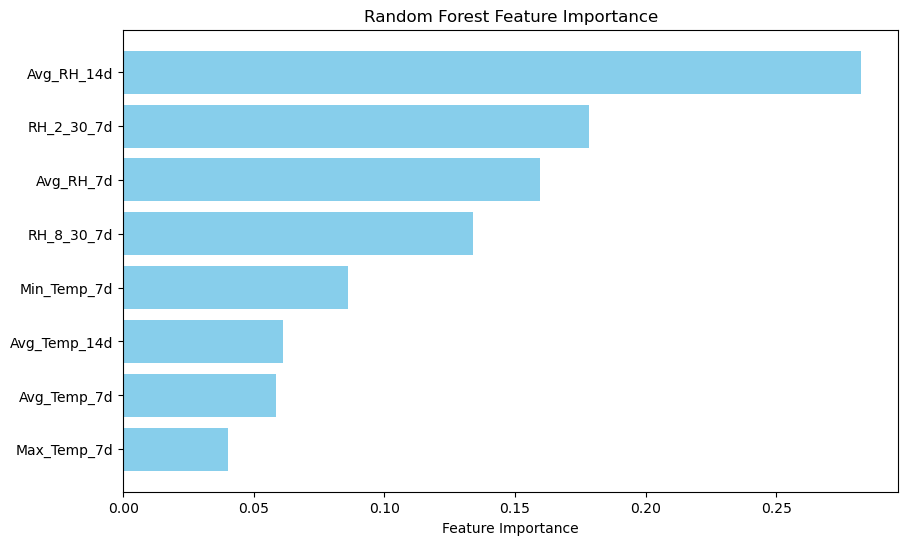

Model saved to C:\Users\Suresh Gawande\Desktop\New folder\rf_model_SB.joblib


In [57]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import matplotlib.pyplot as plt

# Use weather-related features as predictors
X = filtered_data[['RH_8_30_7d', 'RH_2_30_7d', 'Avg_Temp_7d', 'Avg_RH_7d','Avg_Temp_14d', 'Avg_RH_14d',
                   'Max_Temp_7d', 'Min_Temp_7d']]
y = filtered_data['Disease_SB_Present']  # Binary target                                                                                                              

# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train the model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Make predictions
y_pred = rf_model.predict(X_test)

# Evaluate the model
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

# Extract feature importances
importances = rf_model.feature_importances_
feature_names = X.columns

# Combine feature names and importances
feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Print feature importances
print("\nFeature Importances:")
print(feature_importance_df)

# Plot feature importance
plt.figure(figsize=(10, 6))
plt.barh(feature_importance_df['Feature'], feature_importance_df['Importance'], color='skyblue')
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.show()
import joblib

# Path to save the Random Forest model
save_path = r'C:\Users\Suresh Gawande\Desktop\New folder\rf_model_SB.joblib'

# Save the trained model
joblib.dump(rf_model, save_path)

print(f"Model saved to {save_path}")


In [ ]:
import pandas as pd
from lifelines import CoxPHFitter



# Convert categorical columns
filtered_data['Trial_name'] = filtered_data['Trial_name'].astype('category').cat.codes
filtered_data['Season'] = filtered_data['Season'].astype('category').cat.codes

data_for_model = filtered_data[['Days', 'Disease_AN_Present',   'Avg_Temp_7d', 'Avg_RH_7d', 'Avg_RH_14d',
                   'Max_Temp_7d', 'Min_Temp_7d','Trial_name']]  # Use the new column

cph = CoxPHFitter()
cph.fit(data_for_model, duration_col='Days', event_col='Disease_AN_Present')
cph.print_summary()
import joblib

# Path to save the CoxPH model
save_path = r'C:\Users\Suresh Gawande\Desktop\New folder\cph_model_SB.joblib'

# Save the CoxPH model
joblib.dump(cph, save_path)

print(f"CoxPH model saved to {save_path}")

C:\Users\Suresh Gawande\AppData\Local\Temp\ipykernel_4480\4215596188.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Trial_name'] = filtered_data['Trial_name'].astype('category').cat.codes
C:\Users\Suresh Gawande\AppData\Local\Temp\ipykernel_4480\4215596188.py:8: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Season'] = filtered_data['Season'].astype('category').cat.codes


<lifelines.CoxPHFitter: fitted with 94 total observations, 26 right-censored observations>
             duration col = 'Days'
                event col = 'Disease_AN_Present'
      baseline estimation = breslow
   number of observations = 94
number of events observed = 68
   partial log-likelihood = -140.04
         time fit was run = 2024-12-30 11:14:08 UTC

---
             coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                    
Avg_Temp_7d  0.12      1.12      0.64           -1.13            1.36                0.32                3.90
Avg_RH_7d    0.47      1.60      0.11            0.27            0.68                1.31                1.97
Avg_RH_14d   0.64      1.89      0.12            0.40            0.88                1.48                2.41
Max_Temp_7d  1.06      2.87      0.23            0.60            1.51                1.82                4.54
Min_Temp_7d -0.85      0.43      0.39           -1.62           -0.08                0.20                0.92
Trial_name   5.38    217.04      0.78            3.84            6.92               46.70             1008.68

             cmp to     z      p  -log2(p)
covariate                                 
Avg_Temp_7d    0.00  0.18   0.86      0.23
Avg_RH_7d      0.00  4.49 <0.005     17.07
Avg_RH_14d     0.00  5.15 <0.005     21.89
Max_Temp_7d    0.00  4.51 <0.005     17.25
Min_Temp_7d    0.00 -2.17   0.03      5.08
Trial_name     0.00  6.86 <0.005     37.12
---
Concordance = 0.92
Partial AIC = 292.08
log-likelihood ratio test = 164.18 on 6 df
-log2(p) of ll-ratio test = 106.68

CoxPH model saved to C:\Users\Suresh Gawande\Desktop\New folder\cph_model_SB.joblib


In [61]:
import pandas as pd

# Assuming filtered_data is your dataset
# List of significant weather covariates
significant_covariates = ['Avg_RH_7d', 'Avg_RH_14d', 'Max_Temp_7d', 'Min_Temp_7d']

# Define the percentiles to use (e.g., 25th, 50th, 75th percentiles)
percentiles = [0.25, 0.5, 0.75]

# Calculate the thresholds for each covariate based on percentiles
thresholds = {}
for covariate in significant_covariates:
    thresholds[covariate] = {
        '25th_percentile': filtered_data[covariate].quantile(0.25),
        '50th_percentile': filtered_data[covariate].quantile(0.5),
        '75th_percentile': filtered_data[covariate].quantile(0.75)
    }

# Print the calculated thresholds for each covariate
for covariate, threshold_values in thresholds.items():
    print(f"Thresholds for {covariate}:")
    for percentile, value in threshold_values.items():
        print(f"  {percentile}: {value}")
    print()
    
# Example: Filter data based on 75th percentile threshold for Avg_RH_7d
threshold_value = thresholds['Avg_RH_7d']['75th_percentile']
filtered_data['Avg_RH_7d_high'] = filtered_data['Avg_RH_7d'] > threshold_value

# Now you can use this filtered data in your analysis or model


Thresholds for Avg_RH_7d:
  25th_percentile: 52.811458335
  50th_percentile: 62.01372408
  75th_percentile: 66.04206177

Thresholds for Avg_RH_14d:
  25th_percentile: 56.02717888
  50th_percentile: 64.11531887
  75th_percentile: 66.45995195

Thresholds for Max_Temp_7d:
  25th_percentile: 30.5749999975
  50th_percentile: 32.3
  75th_percentile: 34.0642857125

Thresholds for Min_Temp_7d:
  25th_percentile: 12.403571427500001
  50th_percentile: 13.4
  75th_percentile: 14.82857143



C:\Users\Suresh Gawande\AppData\Local\Temp\ipykernel_4480\2885599313.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered_data['Avg_RH_7d_high'] = filtered_data['Avg_RH_7d'] > threshold_value
